# Patient groupings and archetypes

---
**NOTE**  
This is an advanced user notebook. Familiarity with mc-ASTRA patient maps and MOFA-based multicellular factor analysis is assumed.

---

Patient maps generated with mc-ASTRA can be explored in several complementary ways. Clustering identifies groups of similar patients, whereas **archetypal analysis** focuses on the boundaries of patient variation.

In this tutorial, we apply archetypal analysis with `parTIpy` to mc-ASTRA factor scores to identify **archetypal patients**: characteristic extreme states that define the limits of the observed multicellular variation. We then interpret these states by reconstructing their cell-type-specific molecular programs.

---

## Why Archetypal Analysis?

Patients with the same disease rarely follow a single molecular trajectory. Instead, their tissues may show different combinations of inflammatory activation, stromal remodeling, vascular dysfunction, metabolic adaptation, and other coordinated biological processes.

A clustering approach asks:

> **Which group does each patient belong to?**

Archetypal analysis asks a different question:

> **Which extreme patient states define the boundaries of the patient map, and how does each patient relate to those extremes?**

Intuitively, imagine the patient map as a cloud of points. Archetypal analysis identifies a small number of characteristic states near the edges of this cloud. These **archetypes** provide a simplified geometric representation of the observed variation.

Patients within the map can then be described by how strongly they resemble each of these extremes.

For example, rather than separating patients into an *inflammatory group* and a *fibrotic group*, archetypal analysis may identify an inflammation-dominated extreme and a fibrosis-dominated extreme, while representing intermediate patients as combinations of both states.

This is particularly useful for continuous and heterogeneous disease processes, where discrete patient subtypes may provide an incomplete description of the underlying biology.

Within a mc-ASTRA patient map, latent factors provide coordinates that describe multicellular variation across samples. Archetypal analysis summarizes the geometry of this factor space using a small number of extreme patient states.

Because archetypes are defined across several factors simultaneously, each archetype can represent a characteristic **configuration of multicellular programs**, rather than simply a high or low value along a single factor.

---

## Application to human myocardial infarction disease data

We illustrate this workflow using human myocardial infarction (MI) single-cell data.

Following myocardial infarction, cardiac tissue undergoes extensive spatial and temporal remodeling. Tissue samples can differ in inflammatory infiltration, stromal activation, vascular remodeling, cardiomyocyte stress, and tissue repair. These processes are coordinated across multiple cell types and can occur in different combinations across samples.

Here, we re-analyse single-cell data from healthy and infarcted human heart tissue spanning regions and stages of the ischemic-to-fibrotic response, as previously described [here](https://www.nature.com/articles/s41586-022-05060-x).

We first construct a patient map representing each tissue sample through its multicellular factor activities. We then use archetypal analysis to identify characteristic extreme configurations within this latent space, reconstruct their hypothetical features and trace their biological interpretation back to cell-type-specific pathway activities.

---

## Learning goals

- Build a mc-ASTRA patient map from human myocardial infarction single-cell data.
- Interpret disease-associated factors as axes of multicellular variation.
- Apply archetypal analysis to summarize the patient map through characteristic extreme states.
- Interpret archetypes through reconstructed cell-type-specific pathway activities.

---

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)

import mc_astra as mca
import scanpy as sc
import scanpy.external as sce
import numpy as np
import decoupler as dc
import math
import mofaflex as mf
import mudata as md
import pandas as pd
import matplotlib.pyplot as plt
import partipy as pt

/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
import matplotlib as mpl

sc.set_figure_params(
    dpi=120,
    dpi_save=400,
    fontsize=10,
    facecolor="white",
)

mpl.rcParams.update({
    # Typography
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans"],

    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,

    # Cleaner axes
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Vector export
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Export
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
})

## Human myocardial infarction data

The dataset contains single-cell RNA-seq profiles from human myocardial infarction samples. The analysis unit for mc-ASTRA is `patient_region_id`, which combines patient and sampled tissue region. Cell types are treated as separate views, so each patient-region sample is represented by coordinated pseudobulk profiles across cardiomyocytes, fibroblasts, endothelial cells, immune cells, vascular smooth muscle cells, and other detected compartments.

The metadata field `major_labl` stores the regional labels used in the dataset, including `CTRL`, `RZ`, `BZ`, `FZ`, and `IZ`. We use these labels for interpretation, but the model itself is fit without using them as supervision.


In [3]:
adata = sc.read_h5ad("./data/hca_rnasamples.h5ad")

The UMAP below is a cell-level overview of the input object. It is useful for checking the major cell populations and regional labels, but the downstream mc-ASTRA analysis changes the unit of analysis from individual cells to patient-region samples.


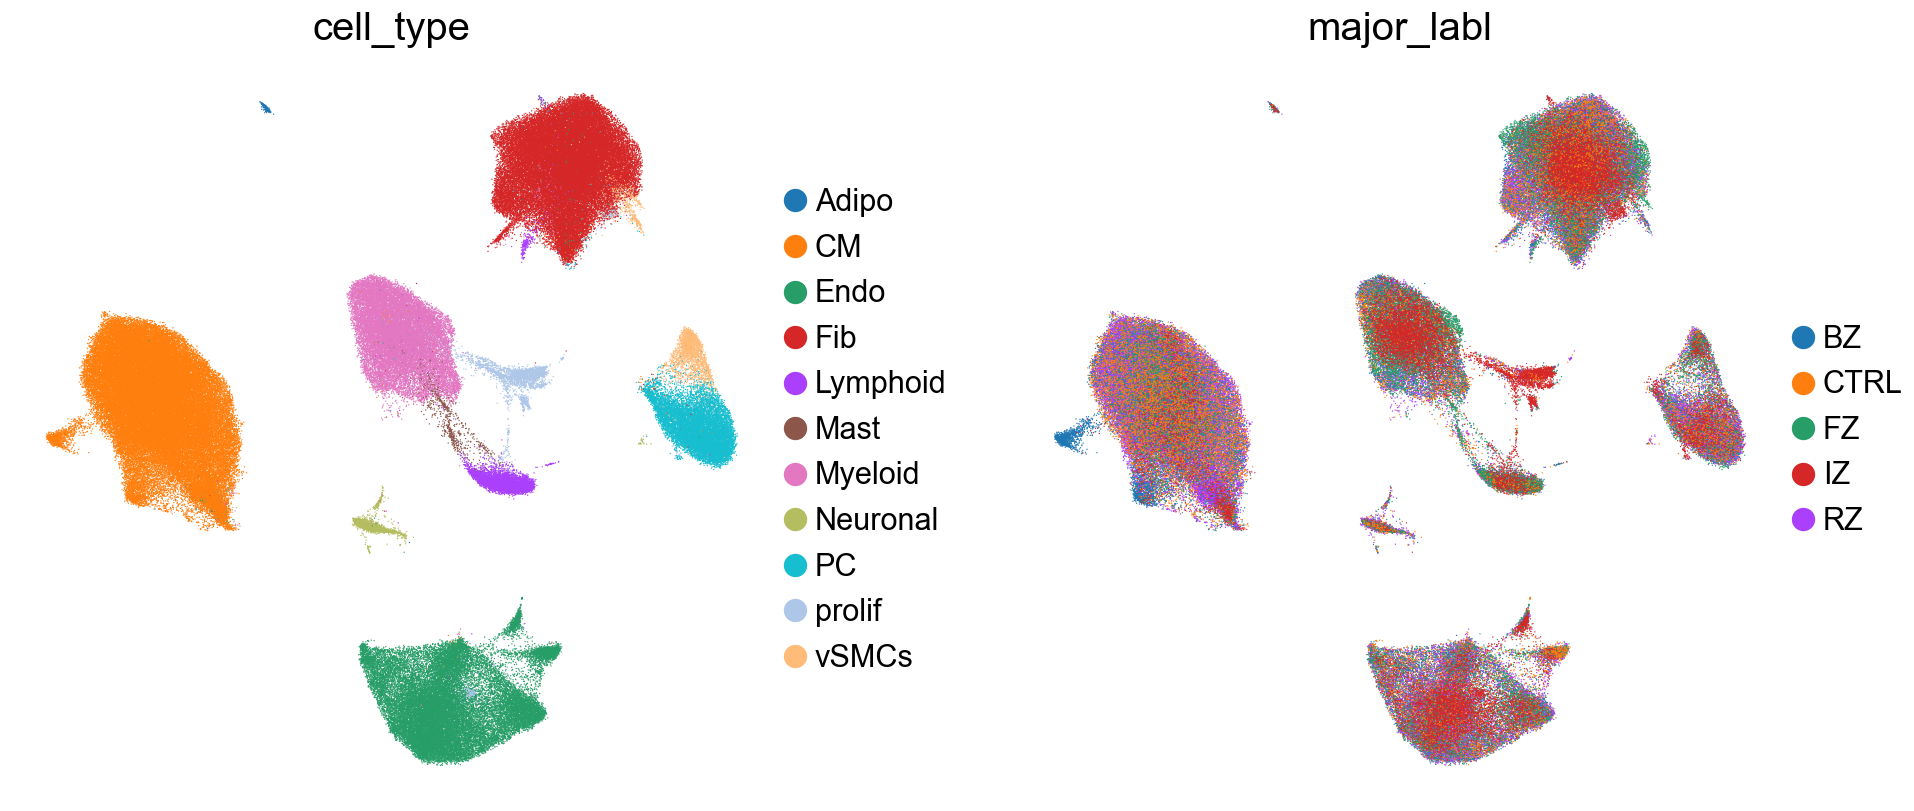

In [4]:
sc.pl.embedding(adata, basis='UMAP_HARMONY', color=['cell_type', "major_labl"], frameon=False, ncols=2)

## Build multicellular patient views

This follows the standard of mc-ASTRA: from pseudobulk to multiview representation

In [5]:
metadata = mca.up.pp.extract_metadata_from_obs(obs = adata.obs,
                                        groupby= 'patient_region_id', 
                                        sort= False)

pdata = dc.pp.pseudobulk(adata, sample_col='patient_region_id', groups_col="cell_type")

# Manipulations on pdata
pdata.obs = pdata.obs.set_index('patient_region_id', drop=False)
pdata.obs.index.name = None

anndata_dict = mca.up.split_anndata_by_celltype(pdata=pdata, grouping="cell_type")

# Adding gene expression total counts - TODO add to upstream as a function

for cell_type, adata in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata.X, "toarray"):
        # Sparse matrix case
        total_counts = adata.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata.X.sum(axis=0)  # numpy array
    
    # Add to .var
    adata.var['total_counts'] = total_counts

mca.up.filt.filter_anndata_by_ncells(anndata_dict, min_cells=10)
# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples =  math.trunc((n_samples * 0.4))

# Run the whole pipeline
mca.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mca.up.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mca.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mca.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.95)
mca.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mca.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, 
                 max_value=None, center=True)
mca.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mca.up.filter_smpls_by_nview(anndata_dict, min_views = 5)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


## Fit a multicellular factor model

We fit an unsupervised MOFA-FLEX model with five factors. In this context, each factor is a sample-level axis of coordinated multicellular variation. A high score for a factor means that a patient-region sample strongly expresses the corresponding cross-cell-type program; a low score means it is closer to the opposite end of that axis.

WARNING	Device cuda is not available. Using default device: cpu


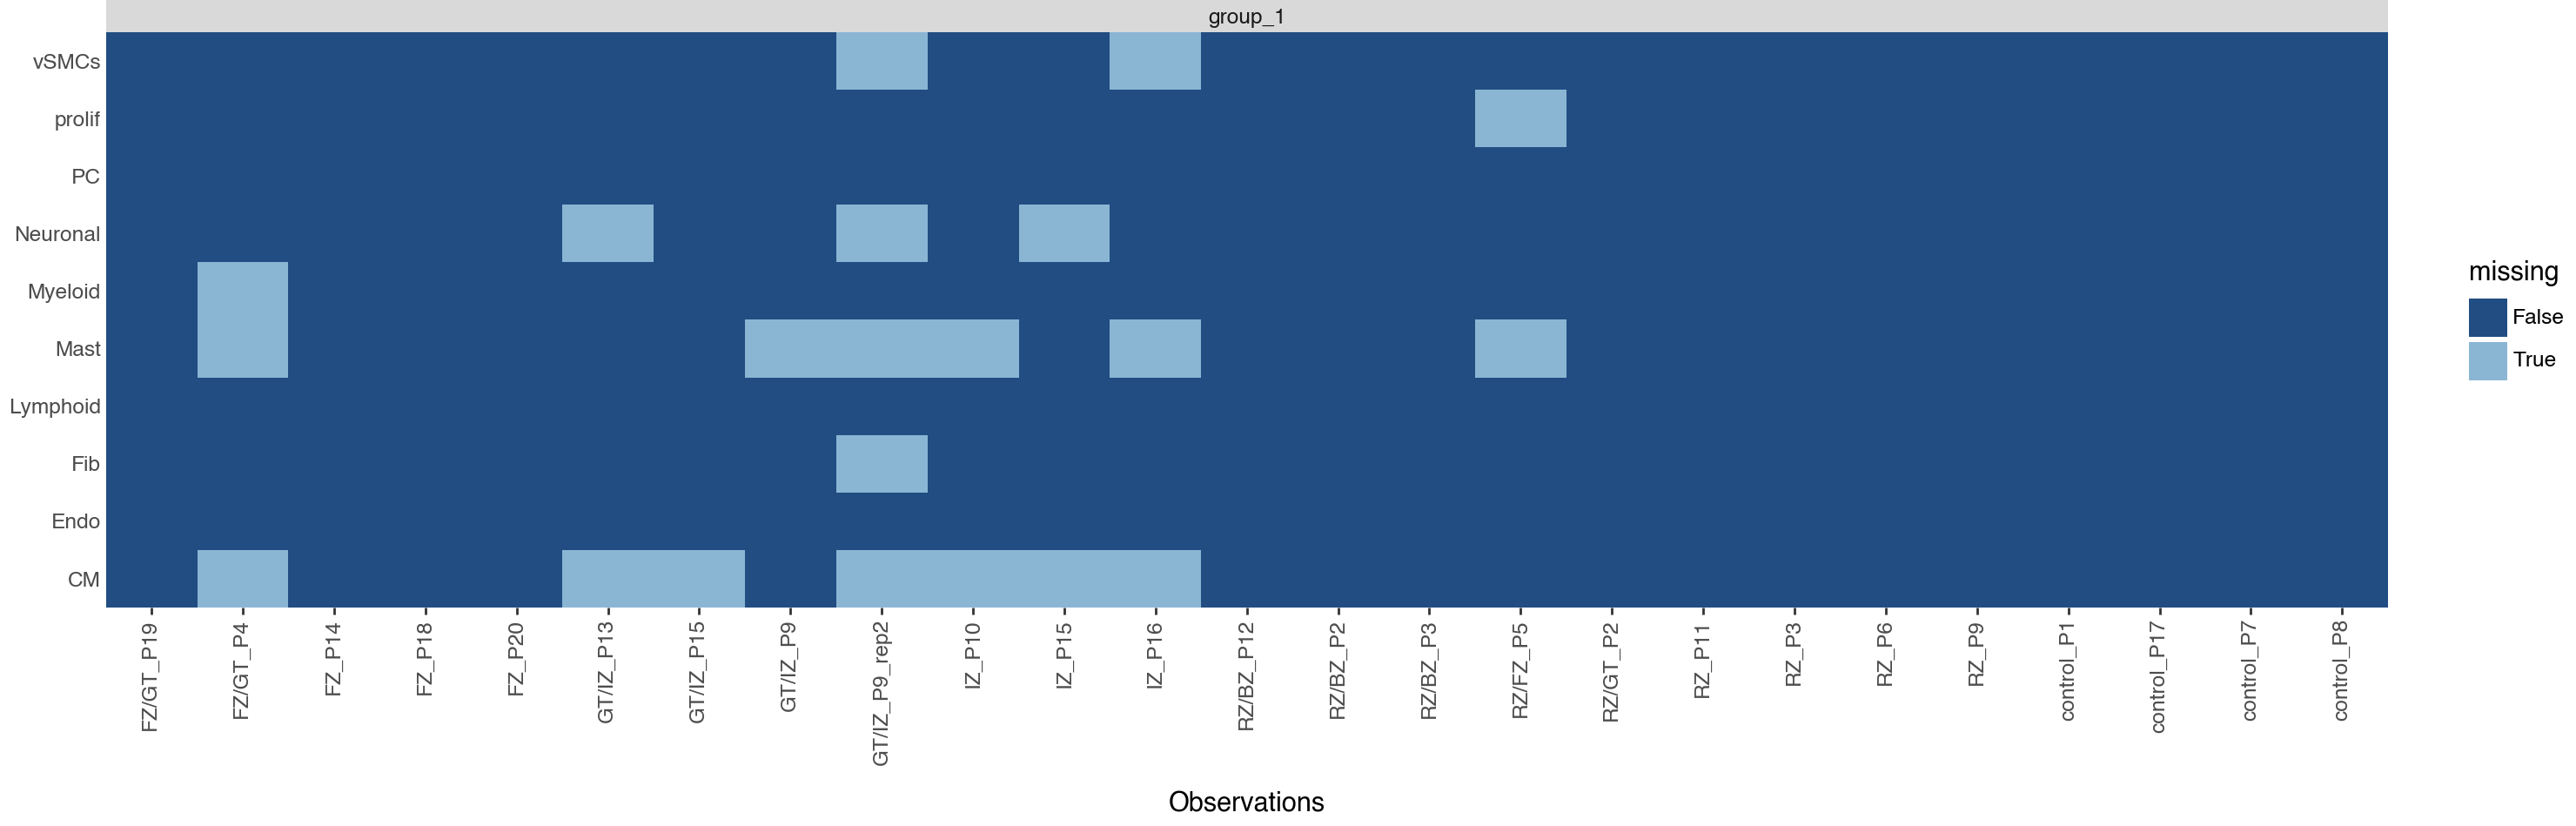

INFO	Initializing factors using 'pca' method...
100%|██████████| 10000/10000 [11:18<00:00, 14.74epoch/s, Loss=3.06e+4]


In [6]:
# Fitting model
# This is necessary before any model fit!
mca.up.utils.append_view_to_var(anndata_dict)
mdata = md.MuData(anndata_dict)
model = mf.terms.MofaFlex(n_factors=5, weight_prior="Horseshoe", init_factors="pca")
model.fit(mdata, seed=42, save_path=False, lr=0.001, early_stopper_patience=1000, likelihoods="Normal")

## Convert the model to a patient map

The fitted model is converted into an `AnnData` object. In this object, `.X` contains patient-by-factor scores, `.obs` contains patient and region metadata, and feature-level outputs such as loadings are stored in the usual scverse-compatible locations.

In [7]:
amodel = mca.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

We also remove strong factor-score outliers before downstream visualization and archetype fitting. This keeps the archetypal analysis focused on the main geometry of the patient map rather than on isolated samples. In mc-ASTRA we calculate outliers as samples that are farther than X number of standard deviations from the mean factor score


In [8]:
outliers = mca.down.identify_outliers(amodel, threshold=3)
outliers = [i for i in outliers.values() if i]  # Remove empty lists
# Flatten the list of lists
outliers = [item for sublist in outliers for item in sublist]

amodel.obs['is_outlier'] = [True if i in outliers else False for i in amodel.obs_names]
amodel = amodel[~amodel.obs['is_outlier'], :].copy()  # Remove outliers

## Identify disease-associated axes

Before fitting archetypes, we inspect which factors are associated with the myocardial infarction grouping variable. The association table shows that `Factor1` is the dominant axis associated with `patient_group`, and `Factor5` is also significant after correction. This indicates that disease-related structure is distributed across more than one latent axis.

In [9]:
disease_asscs = mca.down.get_associations(amodel, 
                           test_variable = "patient_group",
                           test_type="categorical",
                           random_effect = None)

print(disease_asscs)

   feature  statistic       p_value  adj_p_value
0  Factor1  32.819912  3.445627e-07     0.000002
1  Factor2   2.875347  7.875614e-02     0.131260
2  Factor3   0.061329  9.406819e-01     0.940682
3  Factor4   2.263886  1.287262e-01     0.160908
4  Factor5   7.568166  3.348805e-03     0.008372


In [10]:
total_var_fraction = mca.down.calc_total_variance(amodel, disease_asscs, pval_thrs=0.05)
pd.DataFrame(total_var_fraction).mean(axis=1)

feature
group_1    0.242514
dtype: float64

## Inspect the patient factor map

The variance plot summarizes how much structure the model captures across views. The violin and scatter plots then show how the first two factors position patient-region samples relative to `major_labl`.

In this fitted representation, `Factor1` separates infarct-zone-like samples from many control, remote, and border-region samples. `Factor2` captures an additional orthogonal gradient that helps distinguish fibrotic/remodeling-like samples from other regions. This is the key motivation for archetypal analysis: the samples are not simply arranged as isolated clusters, but along a disease-region continuum with multiple extremes.


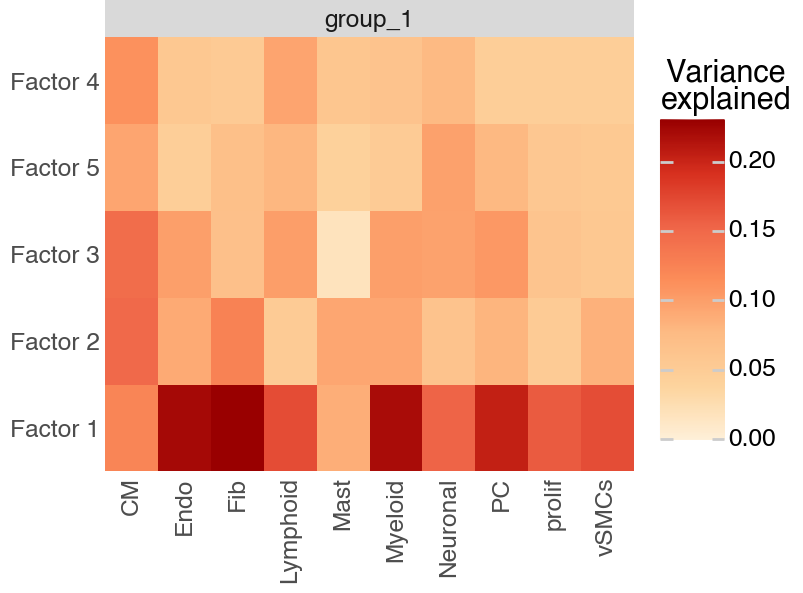

In [11]:
mf.pl.variance_explained(model, figsize=(4, 3))

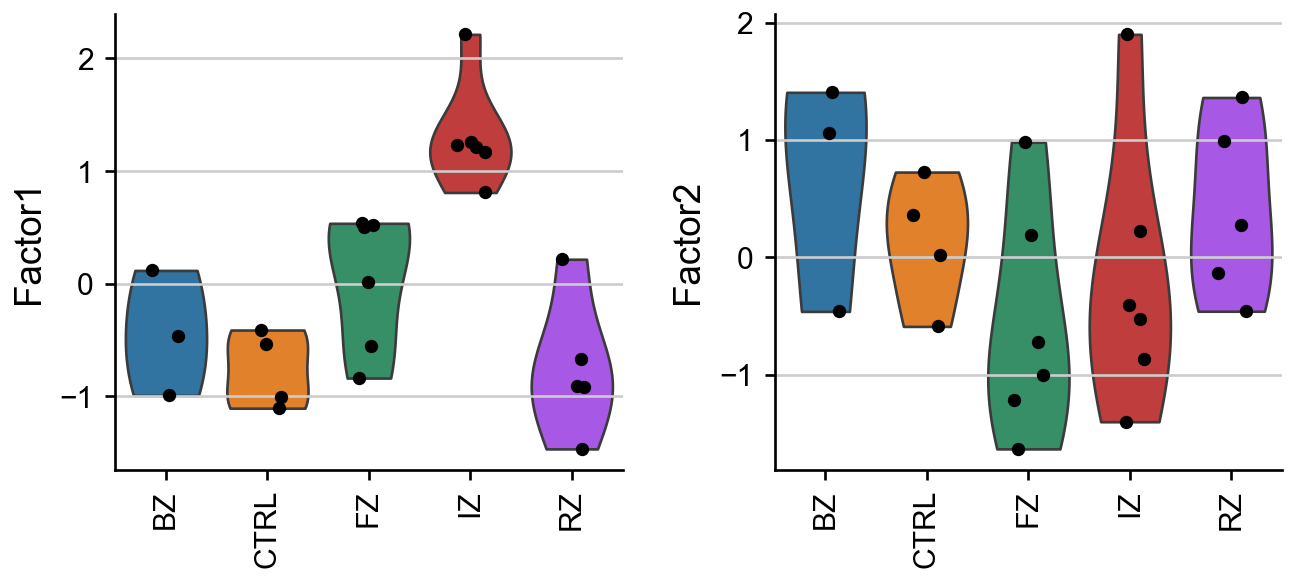

In [12]:
sc.pl.violin(
    amodel,
    ["Factor1", "Factor2"],
    groupby="major_labl",
    jitter=0.15,
    stripplot=True,
    rotation=90,
    dodge=False,
    size=4,
    linewidth=0.8,
    inner=None,
    cut=0,
    show=False,
)

fig = plt.gcf()
fig.set_size_inches(7, 2.5)

for ax in fig.axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="x", pad=3)

fig.tight_layout(w_pad=2)
plt.show()

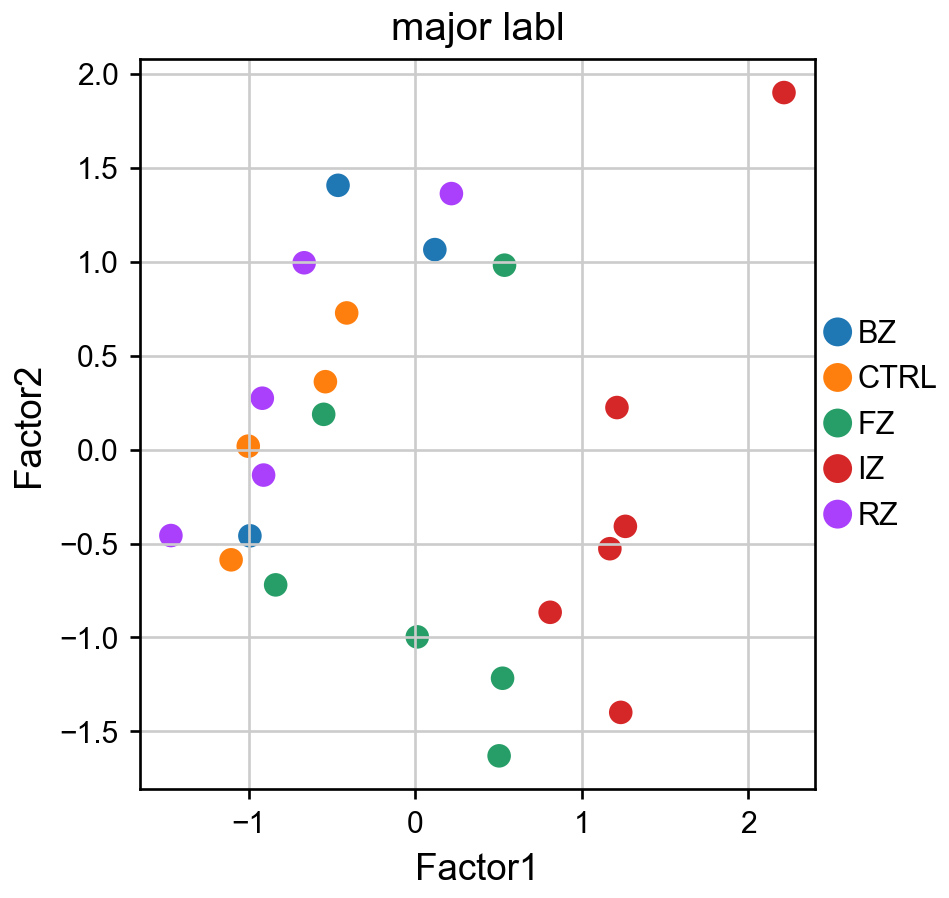

<Figure size 240x300 with 0 Axes>

In [13]:
sc.pl.scatter(amodel,
              x = "Factor1",
              y = "Factor2", 
              color  = "major_labl", 
              size =200)


fig = plt.gcf()
fig.set_size_inches(2, 2.5)

fig.tight_layout(w_pad=2)
plt.show()

## Archetypal analysis of the patient map

Archetypal analysis summarizes a continuous patient map by estimating a small number of extreme points on the boundary of the data cloud. Each patient can then be interpreted by its position relative to those extremes.

This differs from clustering in two important ways. First, archetypes are not average cluster centers; they are boundary states. Second, patients do not need to belong to one archetype only. A patient-region sample can lie between archetypes, reflecting a mixture of multicellular coordination states.

Here we calculate archetypes on the selected factor space and evaluate solutions from two to eight archetypes using variance explained, information criteria, and bootstrap stability.


In [14]:
# The idea is to run archetypal analysis on the factors
# First we need to adapt the data to the format required by partipy

sel_factors = ["Factor1", "Factor2"] # or "all"# This is relative to the factors selected in sel_factors, so if you select "all" it will be relative to all factors
plotting_factors = ["Factor1", "Factor2"]
min_archs = 2,
max_archs = 9,
n_bootstraps = 50

amodel, sel_factors_ix, plotting_factors_ix = mca.down.calculate_pat_archs(amodel,
                        sel_factors, # or "all"# This is relative to the factors selected in sel_factors, so if you select "all" it will be relative to all factors
                        plotting_factors,
                        min_archs = 2,
                        max_archs = 9,
                        n_bootstraps = 50)

/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
/Users/flores/Dropbox/EBI/Research/mc_astra_docs/.venv/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated

The selection diagnostics help choose a parsimonious number of archetypes. In this run, moving from two to three archetypes captures most of the additional factor-space structure, while larger numbers add complexity with less obvious interpretive gain. We therefore use three archetypes for the biological interpretation.


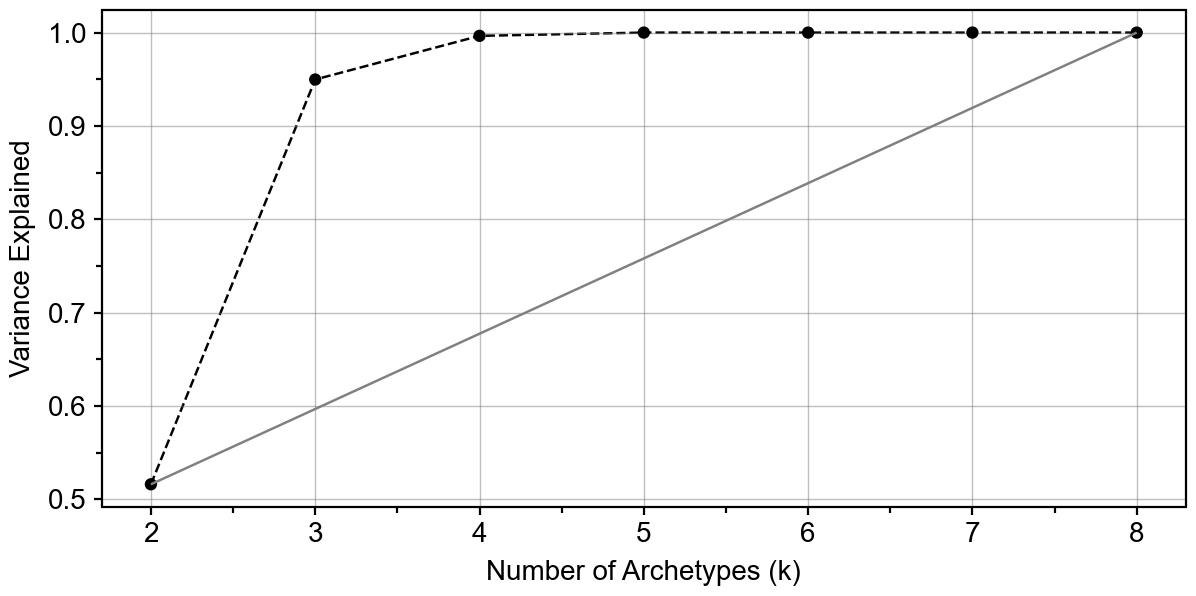

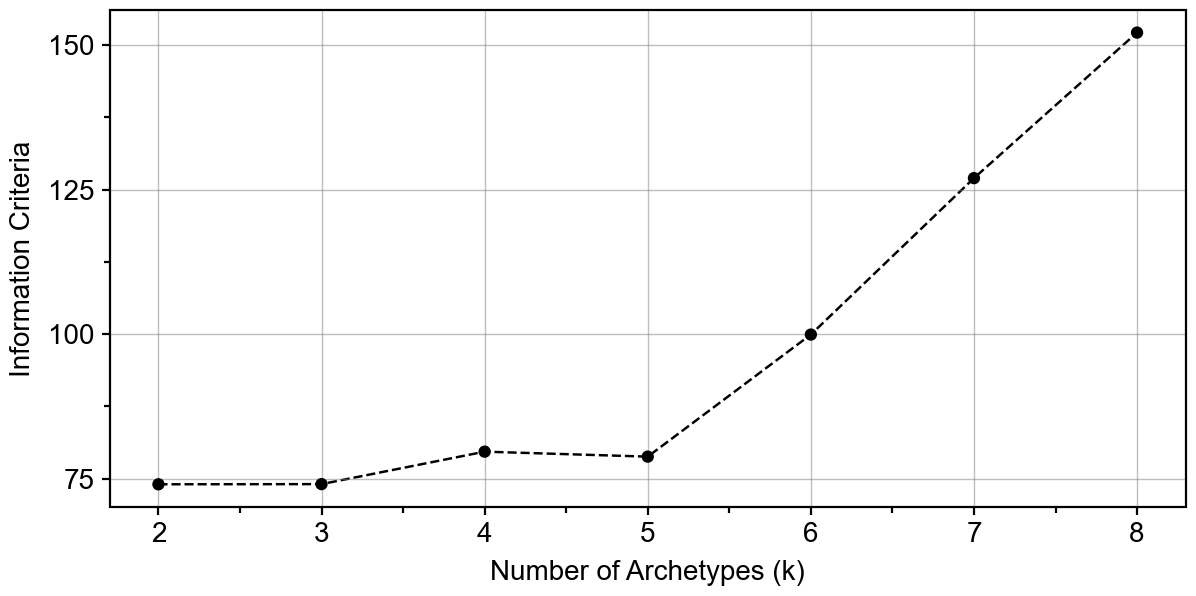

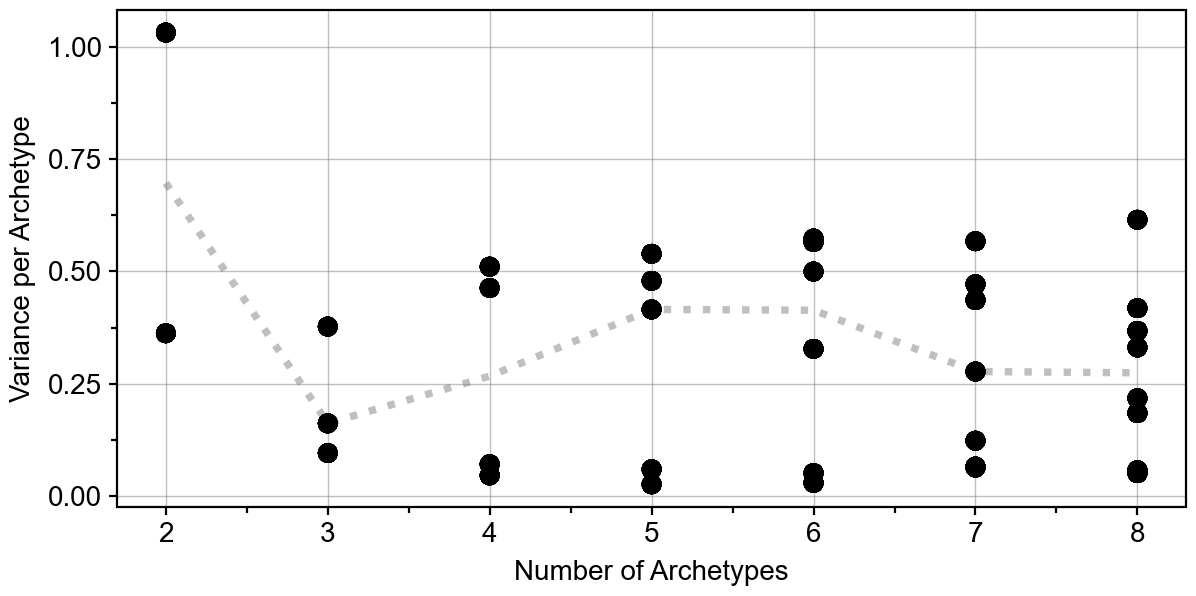

In [15]:
# Plot the selection metrics
p1 = pt.plot_var_explained(amodel)
p2 = pt.plot_IC(amodel)
p3 = pt.plot_bootstrap_variance(amodel)

for p in (p1, p2, p3):
    display(p)

## Reconstruct archetypal patient programs

After selecting three archetypes, we project those archetypal patient states back into the gene-expression feature space. This creates archetype-specific profiles for each cell-type view. This is simply done by multiplying the location of the archetypes in the factor space with their corresponding feature weights.

In [16]:
arch_gex = mca.down.get_arch_pats_values(amodel,
                         n_archetypes = 3,
                         sel_factors_ix = sel_factors_ix)

## Interpret the archetypes in factor space

The plot below overlays the three archetypes on the patient factor map. The triangle is the archetypal simplex: samples inside the triangle can be read as mixtures of the three extreme states.


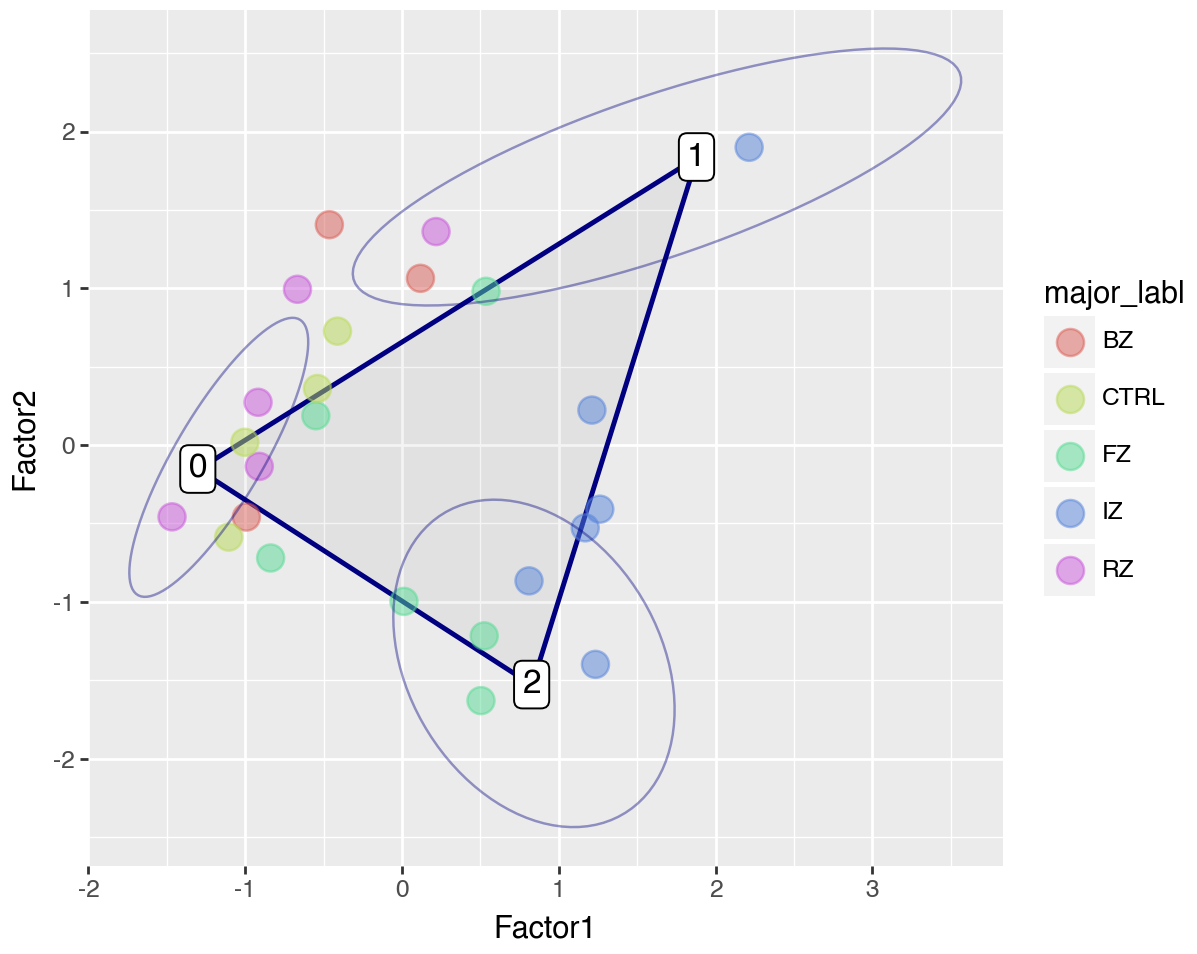

In [17]:
from plotnine import xlab, ylab

aa_plot = pt.plot_archetypes_2D(adata=amodel, dimensions = plotting_factors_ix, 
                      show_contours=True, 
                      result_filters={"n_archetypes": 3, "delta": 0.0},
                      color = "major_labl",
                      size = 5,
                      contours_size=0.5, 
                      contours_alpha=0.4)

aa_plot = (
    aa_plot
    + xlab(sel_factors[plotting_factors_ix[0]])
    + ylab(sel_factors[plotting_factors_ix[1]])
)

aa_plot

In this myocardial infarction dataset, the three archetypes can be read as patient-region extremes rather than hard patient classes:

- `Arch0` is the low-`Factor1` pole, enriched for control, remote, and border-region-like samples. It represents the baseline or less infarct-associated end of the multicellular map.
- `Arch1` lies at high `Factor1` and high `Factor2`, near infarct-zone samples. It represents an extreme injury-associated coordination state.
- `Arch2` lies at high `Factor1` and low `Factor2`, near fibrotic and infarct-remodeling-like samples. It captures a second disease-associated extreme that is distinct from the high-`Factor2` infarct pole.

The important point is that the central samples are not forced into discrete clusters. They can be interpreted as intermediate mixtures, which is often more realistic for complex diseases where inflammation, tissue damage, and repair programs vary continuously.


## Functional interpretation of archetypal patients

We then use PROGENy pathway signatures with `decoupler` to summarize these reconstructed profiles as pathway activities. This translates geometric extremes in the patient map into interpretable multicellular biology.

The baseline-like archetype (0) is comparatively depleted for many disease-associated pathway activities. Archetype 1 and 2 show a trade-off between fibrotic and inflammatory responses.

This connects the geometric interpretation back to biology: archetypes are not just points in a plot, but reconstructed multicellular states that can be inspected through cell-type-specific pathway activity.


Running ULM for view: CM
Running ULM for view: Endo
Running ULM for view: Fib
Running ULM for view: Lymphoid
Running ULM for view: Mast
Running ULM for view: Myeloid
Running ULM for view: Neuronal
Running ULM for view: PC
Running ULM for view: prolif
Running ULM for view: vSMCs


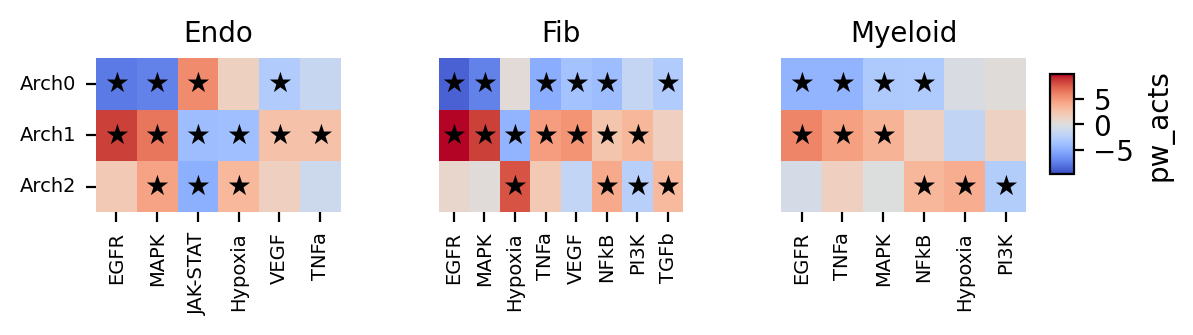

In [19]:
# Make a dictionary of gene expression data of archetypes
arch_gex = mca.down.split_by_view(arch_gex)

# Prepare decoupler
progeny = dc.op.progeny(organism="human")
arch_pws = mca.down.run_ulm_per_view(view_dict=arch_gex, net=progeny)
red_arch_pws = {key: value for key, value in arch_pws.items() if key in ["Fib", "Myeloid", "Endo"]}

mpl.rcParams.update(mpl.rcParamsDefault)

mca.pl.plot_mcell_funcomics(red_arch_pws, 
                     p_threshold=0.05,
                     top_n=10,
                     use_var=True,
                     figsize=(6, 1), center=0)

## Summary

This notebook shows how mc-ASTRA patient maps can be used beyond clustering. After fitting a multicellular factor model to human myocardial infarction data, we used archetypal analysis to identify extreme patient-region states that define the limits of the factor space.

The resulting archetypes summarize a continuum from baseline or less infarct-associated samples, through infarct-zone-like injury states, to fibrotic/remodeling-like states. Because each sample can be positioned relative to all archetypes, this approach is useful when multiple factors contribute to disease heterogeneity and when patient states are better understood as mixtures of coordinated multicellular programs than as isolated clusters.
